In [1]:
from langgraph.graph import StateGraph, START, END
from typing import Literal
import random 
from IPython.display import Image, display 
from typing_extensions import TypedDict
from IPython.display import display, Image

In [2]:
class State(TypedDict):
     name : str
     age : int 

In [3]:
# Will be used as conditional edge 
def decide_process(state : State) -> Literal["minor", "major"]:
     if state['age'] < 18:
          return 'minor'
     else:
          return 'major'

In [4]:
def start_node(state : State) -> State:
    print('Staring the process...')
    return state

def minor_node(state : State) -> State:
    print("Processing Minor : " + state['name'])
    return state 

def major_node(state : State) -> State:
    print("Processing Major : " + state['name'])
    return state


In [5]:
# Build graph
builder = StateGraph(State)
builder.add_node("start_node", start_node)
builder.add_node("minor", minor_node)
builder.add_node("major", major_node)

In [6]:
# Configure the flow of nodes
builder.add_edge(START, "start_node")
builder.add_conditional_edges("start_node", decide_process)
builder.add_edge("minor", END)
builder.add_edge("major", END)

In [7]:
# create graph
graph = builder.compile()

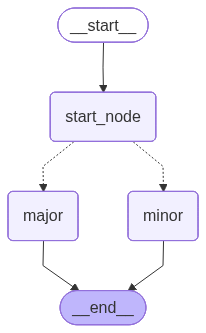

In [8]:
# Display Graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
result = graph.invoke({"name" : "Bill", "age" : 15})
print(result)

Staring the process...
Processing Minor : Bill
{'name': 'Bill', 'age': 15}
